In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
import tensorflow as tf
import keras
import optuna
import shap

In [2]:
# For reproducibility add the same seed. "42" is the standard value.
random_number_seed = 42
np.random.seed(random_number_seed)
keras.utils.set_random_seed(random_number_seed)

#### Help functions

In [3]:
# Function that plots the training and validation for the different epochs.
from matplotlib import legend


def training_validation_history_plot(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.set_theme(style="ticks")
    # Loss plot
    axes[0].plot(history.history['loss'], label='Training Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_xlabel('Epoch', fontsize=16)
    axes[0].set_ylabel('Loss (MSE)', fontsize=16)
    # axes[0].set_title('Model Loss')
    axes[0].grid(True, axis="both", linewidth=0.6, color="black", alpha=0.3)
    axes[0].tick_params(axis='both', labelsize=16)
    legend = axes[0].legend(
        facecolor='white',      # Solid white background
        edgecolor='black',      # Black border
        framealpha=1,           # Fully opaque
        fancybox=True,          # Rounding of the box
)
    legend.get_frame().set_linewidth(0.4) # Changing the thickness of the border
    
    # MAE plot
    axes[1].plot(history.history['mae'], label='Training MAE')
    axes[1].plot(history.history['val_mae'], label='Validation MAE')
    axes[1].set_xlabel('Epoch', fontsize=16)
    axes[1].set_ylabel('MAE', fontsize=16)
    # axes[1].set_title('Model MAE')
    axes[1].grid(True, axis="both", linewidth=0.6, color="black", alpha=0.3)
    axes[1].tick_params(axis='both', labelsize=16)
    legend = axes[1].legend(
        facecolor='white',      # Solid white background
        edgecolor='black',      # Black border
        framealpha=1,           # Fully opaque
        fancybox=True,          # Rounding of the box
)
    legend.get_frame().set_linewidth(0.4) # Changing the thickness of the border
    
    plt.tight_layout()
    plt.show() 

# Performance metrics on the training set
def performance_metrics(Y_train, Y_train_pred, Y_test, Y_test_pred):
    mse_train  = mean_squared_error(Y_train, Y_train_pred)
    rmse_train = np.sqrt(mse_train)
    mae_train  = np.mean(np.abs(Y_train - Y_train_pred))
    r2_train   = r2_score(Y_train, Y_train_pred)
    
    print(f"\nPerformance metrics on the training set:")
    print(f"R² Score: {r2_train:.4f}")
    print(f"MSE:      {mse_train:.2f}")
    print(f"RMSE:     {rmse_train:.2f}%")
    print(f"MAE:      {mae_train:.2f}%")
    
    # Performance metrics on testing set
    mse_test  = mean_squared_error(Y_test, Y_test_pred)
    rmse_test = np.sqrt(mse_test)
    mae_test  = np.mean(np.abs(Y_test - Y_test_pred))
    r2_test   = r2_score(Y_test, Y_test_pred)
    
    print(f"\nPerformance metrics on testing set:")
    print(f"R² Score: {r2_test:.4f}")
    print(f"MSE:      {mse_test:.2f}")
    print(f"RMSE:     {rmse_test:.2f}%")
    print(f"MAE:      {mae_test:.2f}%")

    return mse_train, rmse_train, mae_train, r2_train, mse_test, rmse_test, mae_test, r2_test

def parity_plot(Y_train, Y_train_pred, Y_test, Y_test_pred):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.set_theme(style="ticks")

    # Calculate the metrics
    r2_test   = r2_score(Y_test, Y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(Y_test, Y_test_pred))
    mae_test  = np.mean(np.abs(Y_test - Y_test_pred))
    r2_train  = r2_score(Y_train, Y_train_pred)
    rmse_train = np.sqrt(mean_squared_error(Y_train, Y_train_pred))
    mae_train  = np.mean(np.abs(Y_train - Y_train_pred))
    
    # Test set parity plot
    axes[0].scatter(Y_test, Y_test_pred, alpha=0.6, edgecolors='black', linewidth=0.5)
    min_val = -5
    max_val = 105
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal Prediction')
    axes[0].fill_between([min_val, max_val],
                         [min_val - 10, max_val - 10],
                         [min_val + 10, max_val + 10],
                         alpha=0.2, color='gray', label='±10% Error')
    
    # Create combined legend entry for metrics
    test_metrics_label = f'R² = {r2_test:.3f}\nRMSE = {rmse_test:.2f}%\nMAE = {mae_test:.2f}%'
    
    axes[0].set_xlabel('Experimental Yield (%)', fontsize=16)
    axes[0].set_ylabel('Predicted Yield (%)', fontsize=16)
    axes[0].grid(True, axis="both", linewidth=0.6, color="black", alpha=0.3)
    axes[0].tick_params(axis='both', labelsize=16)
    
    # Create legend with metrics included
    legend = axes[0].legend(
        handles=[
            plt.Line2D([0], [0], color='r', linestyle='--', linewidth=2, label='Ideal Prediction'),
            plt.Rectangle((0,0),1,1, facecolor='gray', alpha=0.2, label='±10% Error'),
            plt.Line2D([0], [0], color='none', label=test_metrics_label)
        ],
        facecolor='white',
        edgecolor='black',
        framealpha=1,
        fancybox=True,
        loc='best'
    )
    legend.get_frame().set_linewidth(0.4)
    
    axes[0].set_xlim(-5, 105)
    axes[0].set_ylim(-5, 105)
    
    # Training set parity plot
    axes[1].scatter(Y_train, Y_train_pred, alpha=0.6, edgecolors='black', linewidth=0.5)
    min_val = -5
    max_val = 105
    axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal Prediction')
    axes[1].fill_between([min_val, max_val],
                         [min_val - 10, max_val - 10],
                         [min_val + 10, max_val + 10],
                         alpha=0.2, color='gray', label='±10% Error')
    
    # Create combined legend entry for metrics
    train_metrics_label = f'R² = {r2_train:.3f}\nRMSE = {rmse_train:.2f}%\nMAE = {mae_train:.2f}%'
    
    axes[1].set_xlabel('Experimental Yield (%)', fontsize=16)
    axes[1].set_ylabel('Predicted Yield (%)', fontsize=16)
    axes[1].grid(True, axis="both", linewidth=0.6, color="black", alpha=0.3)
    axes[1].tick_params(axis='both', labelsize=16)
    
    # Create legend with metrics included
    legend = axes[1].legend(
        handles=[
            plt.Line2D([0], [0], color='r', linestyle='--', linewidth=2, label='Ideal Prediction'),
            plt.Rectangle((0,0),1,1, facecolor='gray', alpha=0.2, label='±10% Error'),
            plt.Line2D([0], [0], color='none', label=train_metrics_label)
        ],
        facecolor='white',
        edgecolor='black',
        framealpha=1,
        fancybox=True,
        loc='best'
    )
    legend.get_frame().set_linewidth(0.4)
    
    axes[1].set_xlim(-5, 105)
    axes[1].set_ylim(-5, 105)
    
    plt.tight_layout()
    plt.show()

def residual_analysis(Y_test, Y_test_pred):

    residuals = Y_test - Y_test_pred
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Residuals vs Predicted
    axes[0].scatter(Y_test_pred, residuals, alpha=0.6, edgecolors='black', linewidth=0.5)
    axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[0].set_xlabel('Predicted Yield (%)')
    axes[0].set_ylabel('Residual (Actual - Predicted) (%)')
    axes[0].set_title('Residuals vs Predicted Values')
    axes[0].grid(True, alpha=0.3)
    
    # Histogram of residuals
    axes[1].hist(residuals, bins=20, edgecolor='black', alpha=0.7)
    axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
    axes[1].set_xlabel('Residual (%)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title(f'Distribution of Residuals\nMean = {residuals.mean():.2f}%, Std = {residuals.std():.2f}%')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def feature_importance(model):
    
    # Using the built in feature importance of Random Forests
    importance_df_rf = pd.DataFrame({
        'Feature': feature_names,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df_rf['Feature'], importance_df_rf['Importance'])
    plt.xlabel('Feature Importance (Mean Decrease in Impurity)')
    plt.title('Random Forest — Feature Importance')
    plt.grid(True, axis="both", linewidth=0.6, color="black", alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("Top 10 most important features:")
    print(importance_df_rf.sort_values('Importance', ascending=False).head(10).to_string(index=False))

### Data preprocessing

##### Data Loading

In [ ]:
# Loading the Perera data
full_data_path=  r"Perera_database - COMPLETE - BASELINE.xlsx"
df = pd.read_excel(full_data_path)

# Loading the ligand descriptor data from KRAKEN database
kraken_data_path = r"KRAKEN - Ligand descriptor database.xlsx"
df_kraken = pd.read_excel(kraken_data_path, sheet_name='dft_targets_SI')

In [5]:
all_descriptor_list = df_kraken.columns.tolist()
print(df_kraken.columns.tolist())

['ID', 'SMILES', 'vmin_vmin_boltz', 'vmin_r_boltz', 'fmo_e_homo_boltz', 'fmo_e_lumo_boltz', 'fmo_mu_boltz', 'fmo_eta_boltz', 'fmo_omega_boltz', 'somo_ra_boltz', 'somo_rc_boltz', 'nbo_P_boltz', 'nbo_P_ra_boltz', 'spindens_P_ra_boltz', 'nbo_P_rc_boltz', 'spindens_P_rc_boltz', 'nmr_P_boltz', 'nmrtens_sxx_P_boltz', 'nmrtens_syy_P_boltz', 'nmrtens_szz_P_boltz', 'efg_amp_P_boltz', 'efgtens_xx_P_boltz', 'efgtens_yy_P_boltz', 'efgtens_zz_P_boltz', 'nuesp_P_boltz', 'E_solv_cds_boltz', 'nbo_lp_P_percent_s_boltz', 'nbo_lp_P_occ_boltz', 'nbo_lp_P_e_boltz', 'nbo_bd_e_max_boltz', 'nbo_bd_e_avg_boltz', 'nbo_bds_e_min_boltz', 'nbo_bds_e_avg_boltz', 'nbo_bd_occ_min_boltz', 'nbo_bd_occ_avg_boltz', 'nbo_bds_occ_max_boltz', 'nbo_bds_occ_avg_boltz', 'E_solv_total_boltz', 'E_solv_elstat_boltz', 'E_oxidation_boltz', 'E_reduction_boltz', 'fukui_p_boltz', 'fukui_m_boltz', 'vbur_vtot_boltz', 'vbur_ratio_vbur_vtot_boltz', 'Pint_P_int_boltz', 'Pint_dP_boltz', 'Pint_P_min_boltz', 'Pint_P_max_boltz', 'volume_boltz'

##### QM features extraction from KRAKEN database and appending to DataFrame

In [6]:
# This code is to append descriptors from the KRAKEN database to the DataFrame.
# Selected ligand descriptors
descriptor_list = [
    'vbur_vbur_min',
    'nbo_lp_P_e_boltz',
    'vbur_vtot_boltz',
    'sterimol_L_boltz', 
    'fmo_e_homo_boltz',
    'nuesp_P_boltz'
]

all_steric_descriptor_list = [
    'sphericity_boltz',
    'surface_area_boltz',
    'volume_boltz',
    'pyr_P_boltz',
    'pyr_alpha_boltz',
    'sterimol_burB1_boltz',
    'sterimol_burB5_boltz',
    'sterimol_burL_boltz',
    'sterimol_B1_boltz',
    'sterimol_B5_boltz',
    'sterimol_L_boltz',
    'vbur_vbur_boltz',
    'vbur_max_delta_qvbur_boltz',
    'vbur_ovbur_max_boltz',
    'vbur_ovtot_max_boltz',
    'vbur_qvbur_max_boltz',
    'vbur_qvtot_max_boltz',
    'vbur_max_delta_qvtot_boltz',
    'vbur_ovbur_min_boltz',
    'vbur_ovtot_min_boltz',
    'vbur_qvbur_min_boltz',
    'vbur_qvtot_min_boltz',
    'vbur_vtot_boltz',
    'vbur_ratio_vbur_vtot_boltz',
    'vbur_near_vbur_boltz',
    'vbur_near_vtot_boltz',
    'vbur_far_vbur_boltz',
    'vbur_far_vtot_boltz'
]

selected_ligand_descriptor_list = [
    'sphericity_boltz',
    'vbur_vbur_boltz',
    'sterimol_burB5_boltz',
    'fmo_eta_boltz',
    'fmo_omega_boltz',
    'fukui_m_boltz'
]

selected_aryl_descriptor_list = [
    'aryl_LUMO',
    'aryl_Electrophilicity',
    'aryl_HOMO-LUMO gap',
]

selected_boron_descriptor_list = [
    'boron_HOMO',
    'boron_Nucleofugality',
    'boron_Chem. potential'
]

selected_solvent_descriptor_list = [
    'solvent_Dipole module',
    'solvent_G solv. in H2O',
    'solvent_Polarizability'
]

def append_ligand_descriptors(df, df_kraken, descriptor_list):
    # Get all the unique ligand smiles from the database
    unique_ligand_smiles = df['ligand_smiles'].unique()

    # Create a DataFrame from the KRAKEN database where only the SMILES from the dataset are in there
    df_kraken_filtered = df_kraken[df_kraken['SMILES'].isin(unique_ligand_smiles)]

    # As can be seen, the XanthPhos is not recognized, because it is not in the KRAKEN database
    df_kraken_filtered.shape

    # Create a dictionary from the KRAKEN database with the SMILES and descriptors
    dict_kraken = {}
    for idx, row in df_kraken_filtered.iterrows():
        smiles = row['SMILES']
        dict_kraken[smiles] = {desc: row[desc] for desc in descriptor_list}

    print(f"KRAKEN database dictionary: {dict_kraken} \n")

    # Iterate through the database with reactions and add the descriptors as columns
    for idx, row in df.iterrows():
        smiles = row['ligand_smiles']

        if smiles in dict_kraken:
            for desc in descriptor_list:
                df.at[idx, f"ligand_{desc}"] = dict_kraken[smiles][desc]
        else:
            for desc in descriptor_list:
                df.at[idx, f"ligand_{desc}"] = None
            print(f"Warning: {smiles} not found in KRAKEN database")

def select_aryl_boron_solvent_descriptors(df, selected_aryl_list, selected_boron_list, selected_solvent_list):
    selected_descriptors = []
    for desc in selected_aryl_list:
        if desc in df.columns and desc.startswith('aryl_'):
            selected_descriptors.append(desc)
    for desc in selected_boron_list:
        if desc in df.columns and desc.startswith('boron_'):
            selected_descriptors.append(desc)
    for desc in selected_solvent_list:
        if desc in df.columns and desc.startswith('solvent_'):
            selected_descriptors.append(desc)

    # Remove other aryl_ and boron_ columns not in the selected lists
    all_aryl_boron_solvent_cols = [col for col in df.columns if col.startswith('aryl_') or col.startswith('boron_') or col.startswith('solvent_')]
    cols_to_drop = [col for col in all_aryl_boron_solvent_cols if col not in selected_descriptors]
    df.drop(columns=cols_to_drop, inplace=True)
    
    return selected_descriptors

# call the function with chosen ligand descriptors
append_ligand_descriptors(df, df_kraken, selected_ligand_descriptor_list)

# Selecting the aryl and boron descriptors
selected_aryl_boron_descriptors = select_aryl_boron_solvent_descriptors(df, selected_aryl_descriptor_list, selected_boron_descriptor_list, selected_solvent_descriptor_list)

KRAKEN database dictionary: {'CC(C)c1cc(C(C)C)c(-c2ccccc2P(C2CCCCC2)C2CCCCC2)c(C(C)C)c1': {'sphericity_boltz': 0.704737109, 'vbur_vbur_boltz': 105.5662868, 'sterimol_burB5_boltz': 7.439480407, 'fmo_eta_boltz': 0.193131047, 'fmo_omega_boltz': 0.03833597, 'fukui_m_boltz': 0.363743942999999}, 'COc1cccc(OC)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1': {'sphericity_boltz': 0.732618381, 'vbur_vbur_boltz': 101.0938553, 'sterimol_burB5_boltz': 7.15627618299999, 'fmo_eta_boltz': 0.196400018999999, 'fmo_omega_boltz': 0.033749737, 'fukui_m_boltz': 0.355754061}, 'CC(C)(C)P(C(C)(C)C)C(C)(C)C': {'sphericity_boltz': 0.889512, 'vbur_vbur_boltz': 65.12848283, 'sterimol_burB5_boltz': 4.894739112, 'fmo_eta_boltz': 0.25289, 'fmo_omega_boltz': 0.016170053, 'fukui_m_boltz': 0.63368}, 'CCCCP(C12CC3CC(CC(C3)C1)C2)C12CC3CC(CC(C3)C1)C2': {'sphericity_boltz': 0.781771957, 'vbur_vbur_boltz': 64.29165019, 'sterimol_burB5_boltz': 6.61531294399999, 'fmo_eta_boltz': 0.237805293999999, 'fmo_omega_boltz': 0.0202438089999999, 'fukui

In [ ]:
# # Delete the datapoints where there is a missing value for either ligands or base, because the model cannot learn from missing values and there are only a few datapoints with missing values.
# df_remaining = df.dropna(subset=['ligand_smiles', 'smiles_base'])

# # Check how much was removed
# original_count = len(df)
# remaining_count = len(df_remaining)
# removed_count = original_count - remaining_count
# removed_percent = (removed_count / original_count) * 100

# print(f"Original rows: {original_count}")
# print(f"Rows after removal: {remaining_count}")
# print(f"Removed rows: {removed_count} ({removed_percent:.1f}%)")
# print(f"Removed {removed_percent:.1f}% of data")

In [7]:
df_test = df.fillna(0)

original_count = len(df)
remaining_count = len(df_test)
removed_count = original_count - remaining_count
removed_percent = (removed_count / original_count) * 100

print(f"Original rows: {original_count}")
print(f"Rows after removal: {remaining_count}")
print(f"Removed rows: {removed_count} ({removed_percent:.1f}%)")
print(f"Removed {removed_percent:.1f}% of data")

has_nan = df_test.isna().any().any()
print(f"Any NaN values? {has_nan}")

Original rows: 512
Rows after removal: 512
Removed rows: 0 (0.0%)
Removed 0.0% of data
Any NaN values? False


### Feature engineering

##### Feature selection

In [8]:
# Seperation of features (inputs) and targets (outputs) of the model
X = df_test.drop(['yield_pct', 'ligand_smiles', 'catalyst',
                       'name_aryl_halide', 'smiles_aryl_halide', 'name_boron_species',
                      'smiles_boron_species', 'name_base', 'smiles_base', 'name_solvent',
                       'smiles_solvent', 'number_reaction', 'precatalyst'], axis = 1)
Y = df_test['yield_pct'].values

categorical_cols = ['name_aryl_halide', 'name_boron_species']
numerical_cols =  X.columns.tolist()

print("Features shape:", X.shape)
print("Features:", X.columns.tolist())
print("Target shape:", Y.shape)

Features shape: (512, 19)
Features: ['time_s', 'temp_c', 'cat_loading', 'aryl_HOMO-LUMO gap', 'aryl_LUMO', 'aryl_Electrophilicity', 'boron_HOMO', 'boron_Chem. potential', 'boron_Nucleofugality', 'solvent_Dipole module', 'solvent_G solv. in H2O', 'solvent_Polarizability', 'base_pka', 'ligand_sphericity_boltz', 'ligand_vbur_vbur_boltz', 'ligand_sterimol_burB5_boltz', 'ligand_fmo_eta_boltz', 'ligand_fmo_omega_boltz', 'ligand_fukui_m_boltz']
Target shape: (512,)


##### Train-test split

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=random_number_seed
)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Input features: {X_train.shape[1]}")

Training set size: 409 samples
Test set size: 103 samples
Input features: 19


###  One run test - Random forest architecture

In [10]:
# Random forest model architecture
def create_rf_model(n_estimators=200, max_depth=None, min_samples_split=2, min_samples_leaf=1, max_features="sqrt"):
    model = RandomForestRegressor(
    n_estimators=n_estimators,       
    max_depth=max_depth,         
    min_samples_split=min_samples_split,    
    min_samples_leaf=min_samples_leaf,      
    max_features=max_features,        
    random_state=random_number_seed,
    n_jobs=-1                
    )

    return model

# Training the RF model
start_training_time = time.time()
rf_model = create_rf_model()
rf_model.fit(X_train, Y_train)
end_training_time = time.time()
print(f"Total training time: {end_training_time - start_training_time:.2f}s")

Total training time: 0.36s


##### Predicting the yield

In [11]:
Y_train_pred_rf = rf_model.predict(X_train)
Y_test_pred_rf  = rf_model.predict(X_test)

#### One run test - Model evaluation

In [12]:
performance_metrics(Y_train, Y_train_pred_rf, Y_test, Y_test_pred_rf)


Performance metrics on the training set:
R² Score: 0.9498
MSE:      34.61
RMSE:     5.88%
MAE:      4.43%

Performance metrics on testing set:
R² Score: 0.6831
MSE:      221.92
RMSE:     14.90%
MAE:      11.48%


(34.60538685122555,
 np.float64(5.8826343462113595),
 np.float64(4.431932323288805),
 0.9498308131104833,
 221.91810719548744,
 np.float64(14.896916029685052),
 np.float64(11.479018425333795),
 0.6830515448688506)

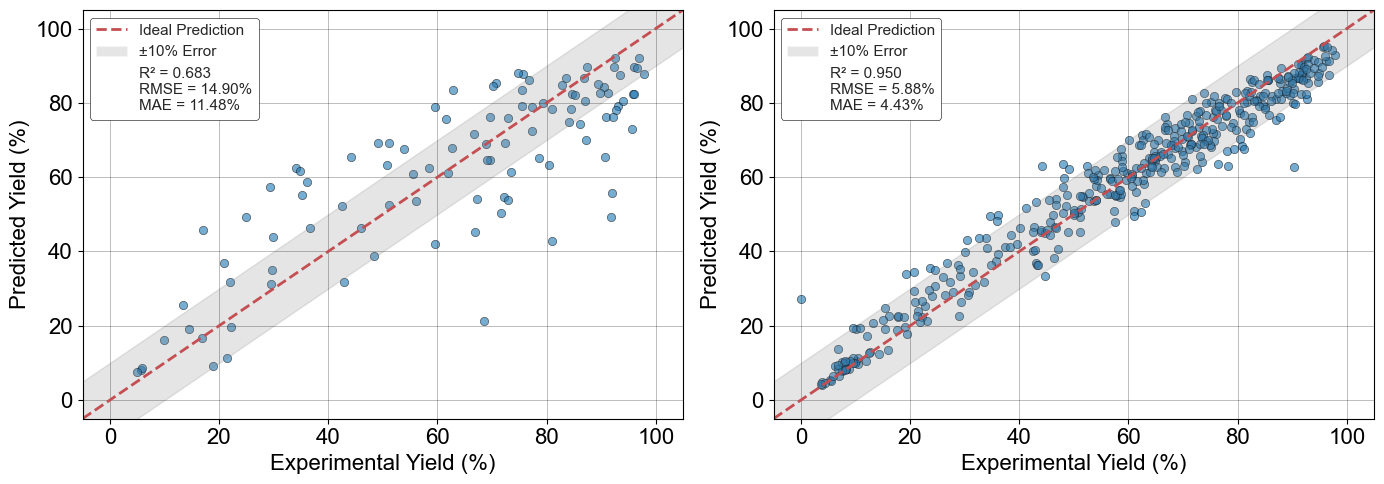

In [13]:
# Executing the parity plot function
parity_plot(Y_train, Y_train_pred_rf, Y_test, Y_test_pred_rf)

### Final model - Hyperparameter optimization using Optuna

In [14]:
# Defining the objective function
def objective(trial):
    # Defining the parameter range over which the optimization is performed. Int are continuous, and categorical not
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 50, 500),
        'max_depth':        trial.suggest_categorical('max_depth', [None, 5, 10, 15, 20]),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':     trial.suggest_categorical('max_features', [1.0, 'sqrt', 0.5, 0.3]),
    }

    rf_optuna = RandomForestRegressor(
    **params,
        random_state=random_number_seed,
        n_jobs=1
    )

    # 5-fold cross validation score for this trial
    scores = cross_val_score(rf_optuna, X_train, Y_train, cv=5, 
                             scoring='neg_root_mean_squared_error', n_jobs=-1) # Calculates the score on the testing set/fold
    return -scores.mean()

In [15]:
# Running the optimization study
start_rf_optuna = time.time()
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=random_number_seed))
study.optimize(objective, n_trials=100, show_progress_bar=True)
best_params = study.best_params
end_rf_optuna = time.time()

# Printing the results
print(f"\nOptuna search completed in {(end_rf_optuna - start_rf_optuna)/60:.1f} minutes")
print(f"Number of finished trials: {len(study.trials)}")
print(f"Best parameters: {study.best_params}")
print(f"Best CV RMSE: {study.best_value:.2f}")

[I 2026-05-05 13:45:36,987] A new study created in memory with name: no-name-17685c76-93c7-438e-967c-5fb25de1d541


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-05-05 13:45:45,337] Trial 0 finished with value: 12.806695744144104 and parameters: {'n_estimators': 218, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 1.0}. Best is trial 0 with value: 12.806695744144104.
[I 2026-05-05 13:45:51,239] Trial 1 finished with value: 14.421420962428925 and parameters: {'n_estimators': 487, 'max_depth': None, 'min_samples_leaf': 6, 'max_features': 0.5}. Best is trial 0 with value: 12.806695744144104.
[I 2026-05-05 13:45:55,309] Trial 2 finished with value: 14.91317114189378 and parameters: {'n_estimators': 181, 'max_depth': 10, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 0 with value: 12.806695744144104.
[I 2026-05-05 13:45:59,033] Trial 3 finished with value: 14.499548321000864 and parameters: {'n_estimators': 477, 'max_depth': None, 'min_samples_leaf': 5, 'max_features': 0.3}. Best is trial 0 with value: 12.806695744144104.
[I 2026-05-05 13:45:59,377] Trial 4 finished with value: 15.957910435946655 and parameters: {'n_

In [ ]:
# import joblib
# # Save the Optuna study
# joblib.dump(study, "BSL1-PER-RF-FINAL.pkl")

['BSL1-PER-RF-FINAL.pkl']

In [ ]:
# # To not run the whole Optuna study again
# import joblib
# # Load the Optuna study
# study = joblib.load("BSL1-PER-RF-FINAL.pkl")
# print(f"Loaded Optuna study with {len(study.trials)} trials")
# best_params = study.best_params
# print(f"Best parameters:\n{print(best_params)}")

Loaded Optuna study with 100 trials
{'n_estimators': 492, 'max_depth': 20, 'min_samples_leaf': 1, 'max_features': 1.0}
Best parameters:
None


In [22]:
optuna.visualization.plot_parallel_coordinate(study)

In [17]:
optuna.visualization.plot_param_importances(study)

### Final model - Evaluation on Optuna model

In [22]:
def run_cross_validation_rf(X, Y, params, n_splits=5, random_state=random_number_seed):

    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    # Making empty list for performance metrics
    mae_per_fold_test  = []
    mae_per_fold_train = []
    r2_per_fold_test   = []
    r2_per_fold_train  = []
    rmse_per_fold_test  = []
    rmse_per_fold_train = []

    # Iterating over the amount of folds and thus also the training and test folds for each
    for fold_no, (train_idx, test_idx) in enumerate(cv.split(X, Y), start=1):
        print(f'Training for fold {fold_no}/{n_splits}')

        # Split data
        train_X = X.iloc[train_idx]
        test_X  = X.iloc[test_idx]
        train_Y = Y[train_idx]
        test_Y  = Y[test_idx]

        # Preprocessing inside each loop to avoid data leakage. Also no target (Y) scaler needed here
        # fold_preprocessor =ColumnTransformer(
        # transformers=[
        #     ('num', StandardScaler(), numerical_cols)
        # ])
        # train_X_transformed = fold_preprocessor.fit_transform(train_X)
        # test_X_transformed  = fold_preprocessor.transform(test_X)

        # Create RF
        fold_rf = RandomForestRegressor(**params, random_state=random_number_seed
        )
        # Train RF
        fold_rf.fit(train_X, train_Y)

        # Predictions
        test_predictions  = fold_rf.predict(test_X)
        train_predictions = fold_rf.predict(train_X)

        # Metrics
        mae_test  = np.mean(np.abs(test_predictions - test_Y))
        mae_train = np.mean(np.abs(train_predictions - train_Y))
        r2_test   = r2_score(test_Y, test_predictions)
        r2_train  = r2_score(train_Y, train_predictions)

        mae_per_fold_test.append(mae_test)
        mae_per_fold_train.append(mae_train)
        r2_per_fold_test.append(r2_test)
        r2_per_fold_train.append(r2_train)
        rmse_per_fold_test.append(np.sqrt(np.mean((test_predictions - test_Y) ** 2)))
        rmse_per_fold_train.append(np.sqrt(np.mean((train_predictions - train_Y) ** 2)))

        print(f"Test  R² = {r2_test:.3f}  |  MAE = {mae_test:.2f}%")
        print(f"Train R² = {r2_train:.3f}  |  MAE = {mae_train:.2f}%")

        # Parity plots per fold
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        for ax, actual, predicted, split_label, r2_val, mae_val in [
            (axes[0], test_Y,  test_predictions,  'Test',  r2_test,  mae_test),
            (axes[1], train_Y, train_predictions, 'Train', r2_train, mae_train),
        ]:
            ax.scatter(actual, predicted, alpha=0.6, edgecolors='black', linewidth=0.5)
            lo, hi = min(actual.min(), predicted.min()), max(actual.max(), predicted.max())
            ax.plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Ideal')
            ax.set_xlabel('Experimental Yield (%)', fontsize=12)
            ax.set_ylabel('Predicted Yield (%)',    fontsize=12)
            ax.set_title(
                f'Parity Plot – {split_label} Set  |  Fold {fold_no}\n'
                f'R² = {r2_val:.3f},  MAE = {mae_val:.2f}%', fontsize=12
            )
            ax.legend()
            ax.grid(True, alpha=0.3)
            ax.set_xlim(-10, 110)
            ax.set_ylim(-10, 110)

        plt.tight_layout()
        plt.show()

    return r2_per_fold_test, r2_per_fold_train, mae_per_fold_test, mae_per_fold_train, rmse_per_fold_test, rmse_per_fold_train


Performance metrics on the training set:
R² Score: 0.9621
MSE:      26.13
RMSE:     5.11%
MAE:      3.76%

Performance metrics on testing set:
R² Score: 0.7426
MSE:      180.21
RMSE:     13.42%
MAE:      10.06%


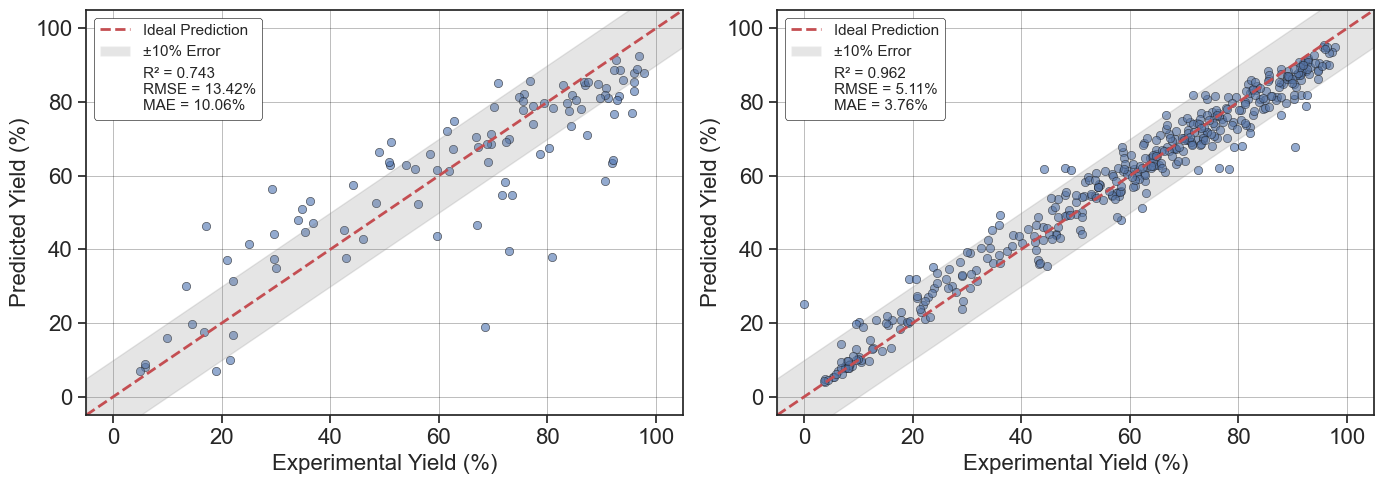

Training for fold 1/5
Test  R² = 0.771  |  MAE = 9.23%
Train R² = 0.959  |  MAE = 4.00%


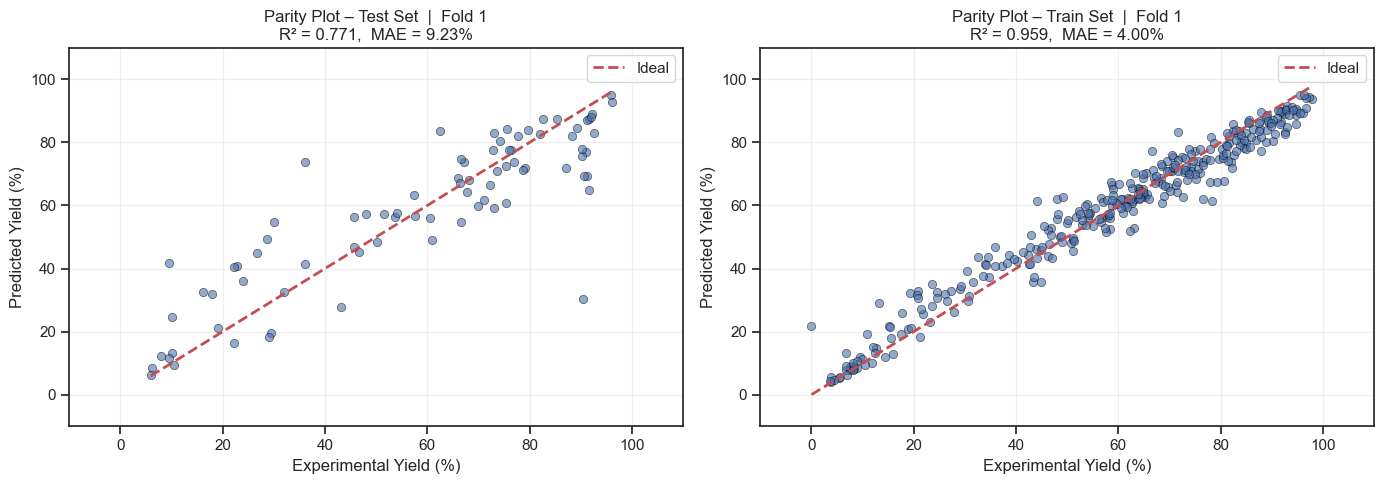

Training for fold 2/5
Test  R² = 0.750  |  MAE = 10.69%
Train R² = 0.962  |  MAE = 3.84%


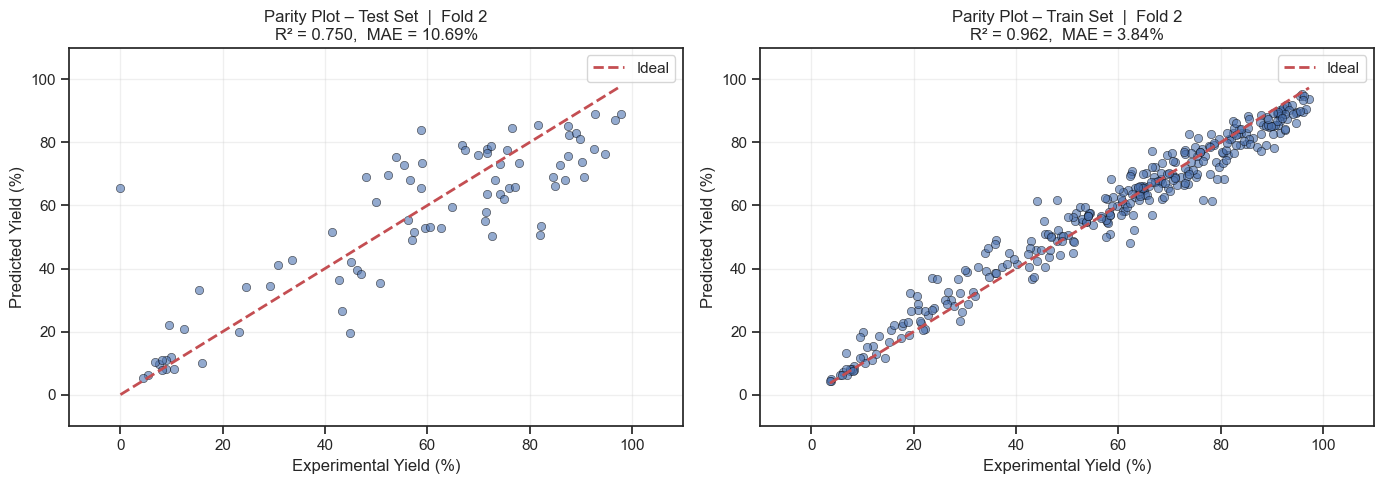

Training for fold 3/5
Test  R² = 0.732  |  MAE = 9.82%
Train R² = 0.963  |  MAE = 3.76%


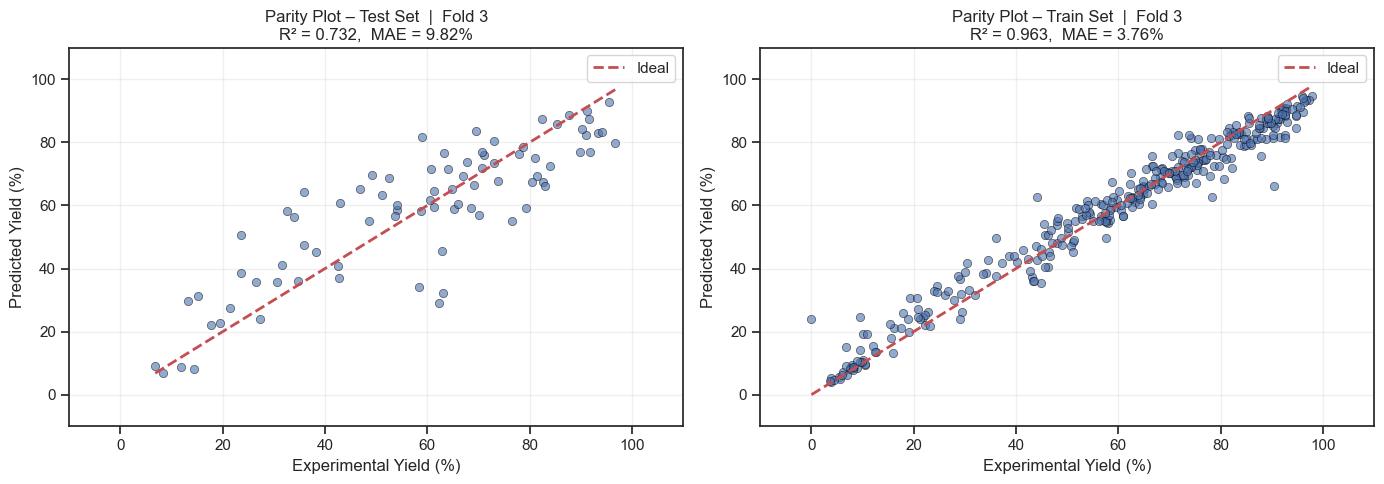

Training for fold 4/5
Test  R² = 0.722  |  MAE = 8.95%
Train R² = 0.962  |  MAE = 3.95%


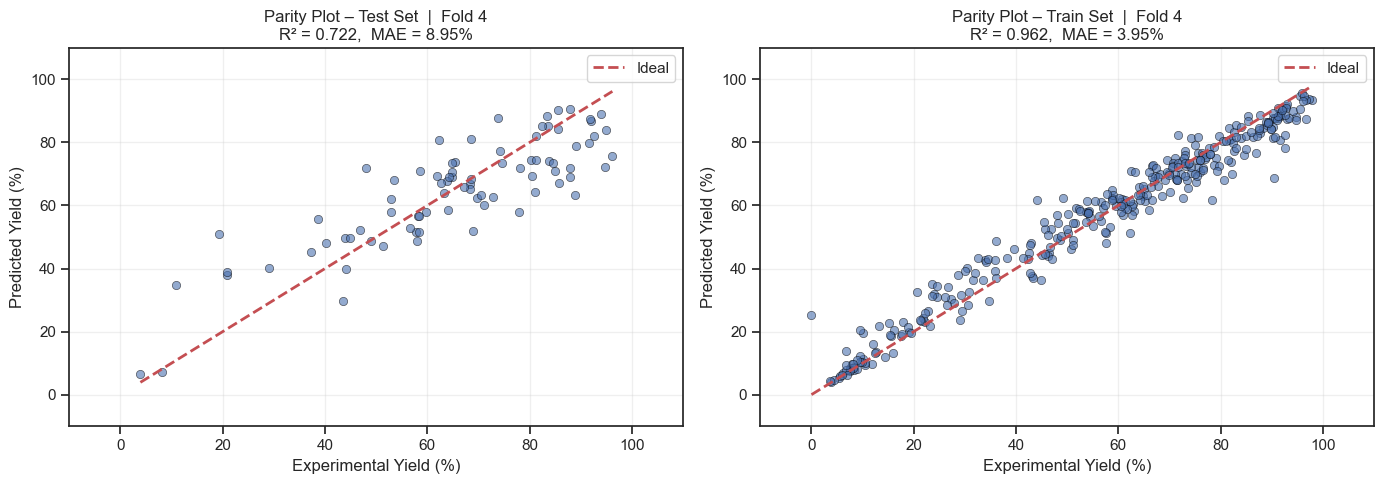

Training for fold 5/5
Test  R² = 0.738  |  MAE = 10.90%
Train R² = 0.962  |  MAE = 3.72%


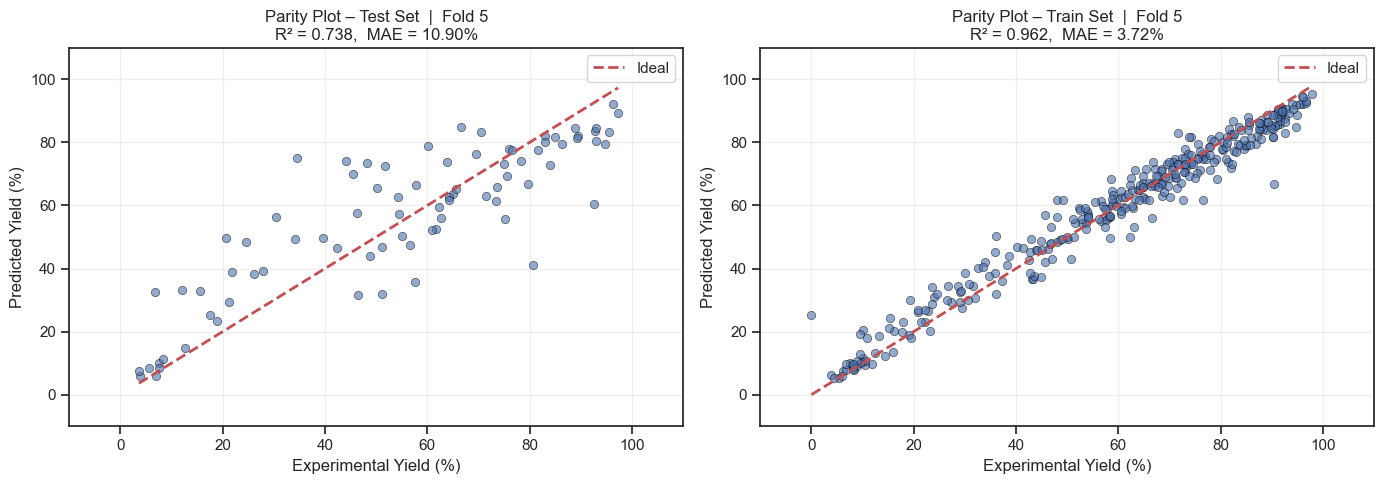


Cross-validation results testing:
MAE: 9.92% ± 0.77%
R²:  0.743 ± 0.01667
RMSE: 13.10% ± 1.07%

Cross-validation results training:
MAE: 3.85% ± 0.11%
R²:  0.962 ± 0.00158
RMSE: 5.14% ± 0.12%


In [23]:
# Making the model
rf_best_model = RandomForestRegressor(random_state=random_number_seed, **study.best_params, n_jobs=-1)

rf_best_model.fit(X_train, Y_train)

# Calculating the target
Y_train_rf_best_model_pred = rf_best_model.predict(X_train)
Y_test_rf_best_model_pred  = rf_best_model.predict(X_test)

# Metrics and plotting
performance_metrics(Y_train, Y_train_rf_best_model_pred, Y_test, Y_test_rf_best_model_pred)
parity_plot(Y_train, Y_train_rf_best_model_pred, Y_test, Y_test_rf_best_model_pred)

# Run cross validation on final model
r2_per_fold_test_rf, r2_per_fold_train_rf, mae_per_fold_test_rf, mae_per_fold_train_rf, rmse_per_fold_test_rf, rmse_per_fold_train_rf = run_cross_validation_rf(X_train, Y_train, params=study.best_params, n_splits=5)

# Summary
print(f'\nCross-validation results testing:')
print(f'MAE: {np.mean(mae_per_fold_test_rf):.2f}% ± {np.std(mae_per_fold_test_rf):.2f}%')
print(f'R²:  {np.mean(r2_per_fold_test_rf):.3f} ± {np.std(r2_per_fold_test_rf):.5f}')
print(f'RMSE: {np.mean(rmse_per_fold_test_rf):.2f}% ± {np.std(rmse_per_fold_test_rf):.2f}%')

print(f'\nCross-validation results training:')
print(f'MAE: {np.mean(mae_per_fold_train_rf):.2f}% ± {np.std(mae_per_fold_train_rf):.2f}%')
print(f'R²:  {np.mean(r2_per_fold_train_rf):.3f} ± {np.std(r2_per_fold_train_rf):.5f}')
print(f'RMSE: {np.mean(rmse_per_fold_train_rf):.2f}% ± {np.std(rmse_per_fold_train_rf):.2f}%')

#### SHAP-analysis of the Optuna best model

In [28]:
background = X_train
explainer = shap.TreeExplainer(rf_best_model, background)
shap_values_raw = explainer.shap_values(X_test)

# Handle both old SHAP (returns list) and new SHAP (returns array directly)
if isinstance(shap_values_raw, list):
    shap_vals = shap_values_raw[0]   # old: list of arrays, one per output
else:
    shap_vals = shap_values_raw      # new: array directly, shape (n_samples, n_features)

# Squeeze in case of shape (n_samples, n_features, 1)
if shap_vals.ndim == 3:
    shap_vals = shap_vals[:, :, 0]

print(f"SHAP values shape: {shap_vals.shape}")         # should be (n_test, n_features)
print(f"X_test_processed shape: {X_test.shape}")  # should match

SHAP values shape: (103, 19)
X_test_processed shape: (103, 19)


C:\Users\livio\AppData\Local\Temp\ipykernel_30064\4024603241.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, X_test, plot_type='bar', show=True)


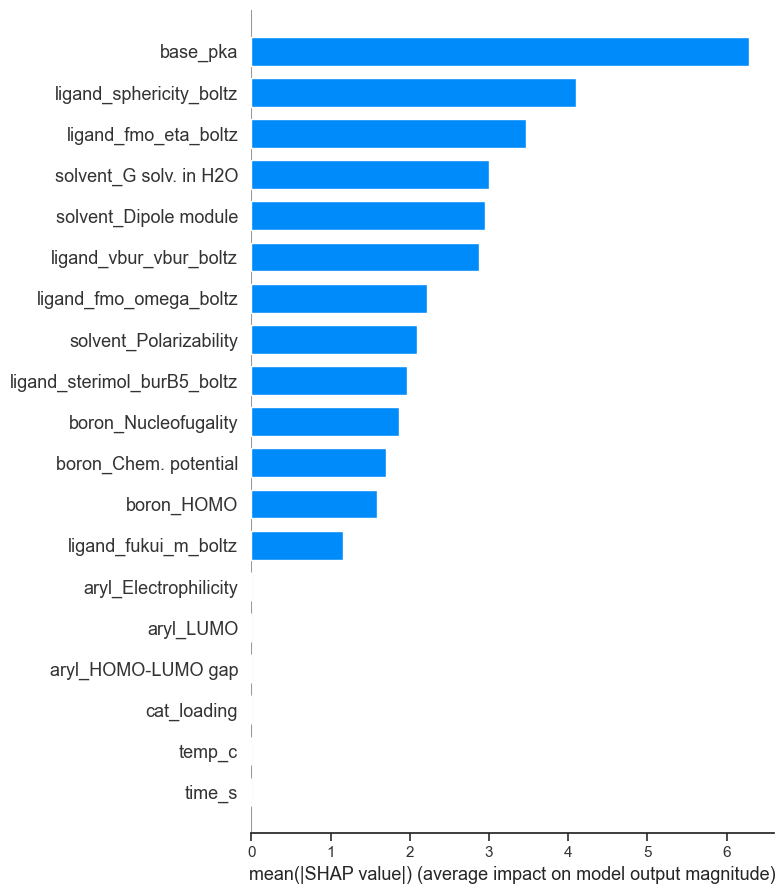

In [29]:
shap.summary_plot(shap_vals, X_test, plot_type='bar', show=True)

C:\Users\livio\AppData\Local\Temp\ipykernel_30064\4081524001.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, X_test, show=True)


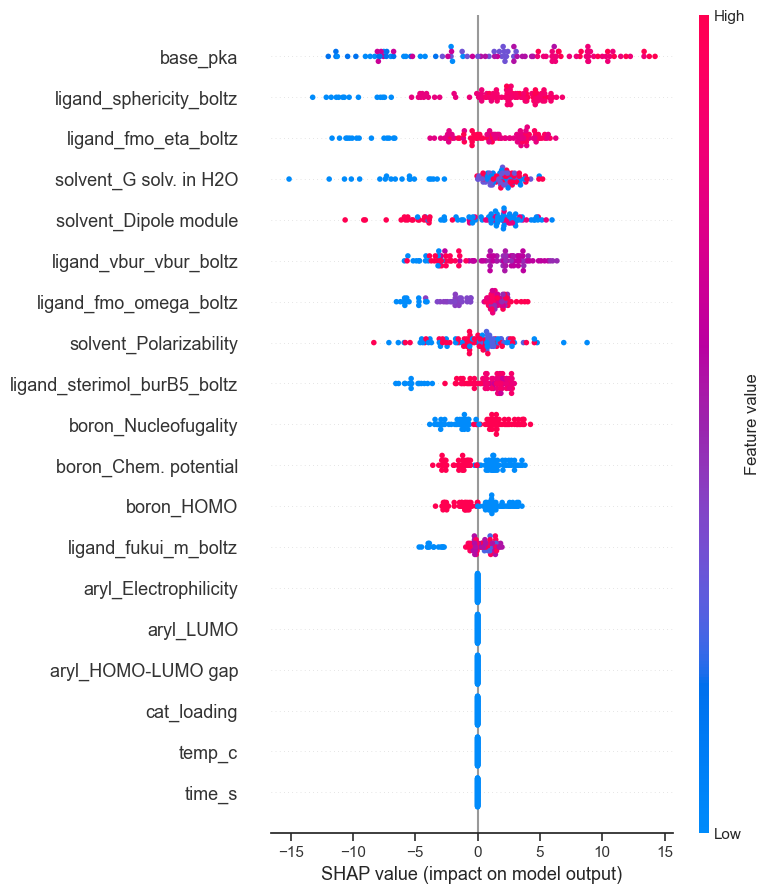

In [30]:
# Beeswarm plot
shap.summary_plot(shap_vals, X_test, show=True)

In [24]:
# Tabular ranking
shap_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'mean_abs_shap': np.abs(shap_vals).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print(shap_importance)

NameError: name 'shap_vals' is not defined

##### Outlier analysis

In [25]:
results_check = pd.DataFrame({
    'y_true': Y_test,
    'y_pred': Y_test_rf_best_model_pred,
    'residual': Y_test - Y_test_rf_best_model_pred,
    'abs_residual': np.abs(Y_test - Y_test_rf_best_model_pred),
    'ligand' : df_test['catalyst'],
    'time': df_test['time_s'],
    'temperautre': df_test['temp_c'],
    'cat loading': df_test['cat_loading'],
    'aryl halide': df_test['name_aryl_halide'],
    'boron species': df_test['name_boron_species']
}, index=X_test.index)

# Find outliers
outliers = results_check.nlargest(10, 'abs_residual')
# # Look them up in the orginal dataframe
# original_df.loc[outliers.index]

In [26]:
import plotly.express as px
import plotly.graph_objects as go

results_check['original_index'] = results_check.index
fig = px.scatter(results_check, x='y_true', y='y_pred', hover_data=['original_index', 'residual'], title='Predicted vs Actual Yields with Residuals')
fig.add_shape(type='line', x0=0, y0=0, x1=100, y1=100, line=dict(color='Red', dash='dash'))
fig.show()

print(outliers)

        y_true     y_pred   residual  abs_residual   ligand  time  \
184  68.498529  18.920034  49.578496     49.578496  P(tBu)3    60   
440  80.941131  37.889857  43.051274     43.051274  P(tBu)3    60   
275  72.867171  39.474736  33.392436     33.392436   P(Cy)3    60   
222  90.686354  58.540624  32.145731     32.145731    XPhos    60   
502  17.110177  46.382672 -29.272494     29.272494    XPhos    60   
304  91.871973  63.384719  28.487254     28.487254  P(tBu)3    60   
296  92.064673  64.317497  27.747177     27.747177  P(tBu)3    60   
247  29.257479  56.292021 -27.034543     27.034543        0    60   
176  66.966870  46.629478  20.337392     20.337392  P(tBu)3    60   
376  95.627330  76.975560  18.651770     18.651770  P(tBu)3    60   

     temperautre  cat loading       aryl halide  \
184          100         6.25  6-bromoquinoline   
440          100         6.25  6-bromoquinoline   
275          100         6.25  6-bromoquinoline   
222          100         6.25  6-bro

In [27]:
results_check['original_index'] = results_check.index
outlier_indices = outliers.index

fig = px.scatter(
    results_check,
    x='y_true',
    y='y_pred',
    color='ligand',                  # <-- color by ligand
    hover_data={
        'original_index': True,
        'residual': ':.2f',
        'ligand': True,
        'aryl halide': True,
        'boron species': True,
        'time': True,
        'temperautre': True,
        'cat loading': True,
    },
    title='Predicted vs Actual Yields — colored by ligand',
    opacity=0.7,
)

# Add dashed perfect-prediction line
fig.add_shape(
    type='line', x0=0, y0=0, x1=100, y1=100,
    line=dict(color='black', dash='dash', width=1)
)

# Overlay outlier ring markers
outlier_data = results_check.loc[outlier_indices]
fig.add_trace(go.Scatter(
    x=outlier_data['y_true'],
    y=outlier_data['y_pred'],
    mode='markers+text',
    marker=dict(size=18, color='rgba(0,0,0,0)', line=dict(color='red', width=2)),
    text=outlier_data.index.astype(str),
    textposition='top center',
    textfont=dict(size=10, color='red'),
    name='Top 10 outliers',
    hoverinfo='skip',               # avoids double tooltip
))

fig.update_layout(
    xaxis_title='Actual yield (%)',
    yaxis_title='Predicted yield (%)',
    legend_title='Ligand',
    width=800, height=600,
)
fig.show()